# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

d:\CODING FILES\Celebal Internship\week4\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

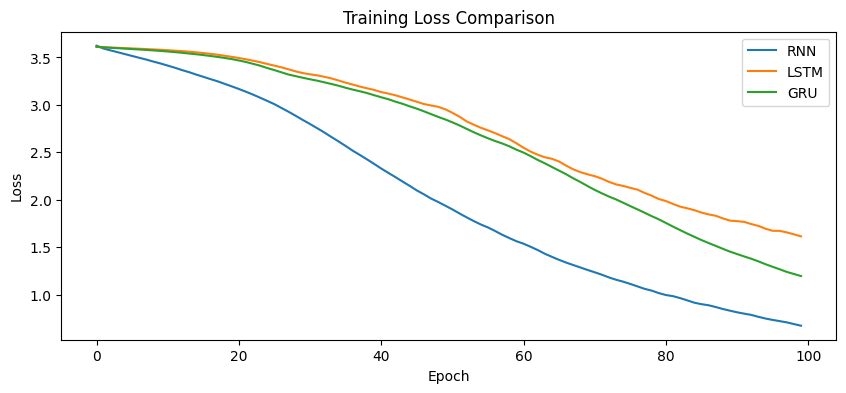

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is transforming artificial intelligence intelligence
GRU : deep learning is can artificial intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# 🛠️ Solution: Implementation of Beginner Tasks
Here, we implement the requested beginner tasks:
1. **Replace corpus with custom paragraph** about AI, seq models, and Deep Learning.
2. **Increase embedding dimension** from 32 to 64.
3. **Increase training epochs** to 200.
4. **Change hidden units** in the RNN/LSTM/GRU layers from 64 to 128.
5. **Generate 10 words** instead of 5 words.


In [10]:
# 1. Define the new corpus (own paragraph)
new_corpus = '''
artificial intelligence is rapidly changing the way we interact with technology
recurrent neural networks excel at processing sequential datasets like text and audio
long short term memory networks solve the vanishing gradient problem in simple rnn
gated recurrent units offer a simplified architecture with fewer parameters and faster training
deep learning models learn grammar patterns to generate coherent and meaningful sentences
with enough training data these models can generate creative stories and song lyrics
natural language processing has evolved significantly with the advent of deep learning
'''
print("New Corpus:")
print(new_corpus.strip())


New Corpus:
artificial intelligence is rapidly changing the way we interact with technology
recurrent neural networks excel at processing sequential datasets like text and audio
long short term memory networks solve the vanishing gradient problem in simple rnn
gated recurrent units offer a simplified architecture with fewer parameters and faster training
deep learning models learn grammar patterns to generate coherent and meaningful sentences
with enough training data these models can generate creative stories and song lyrics
natural language processing has evolved significantly with the advent of deep learning


In [11]:
# 2. Tokenization & Sequence Creation for new corpus
new_tokenizer = Tokenizer()
new_tokenizer.fit_on_texts([new_corpus])

new_total_words = len(new_tokenizer.word_index) + 1
print("New Vocabulary size:", new_total_words)

new_input_sequences = []
for line in new_corpus.strip().split('\n'):
    token_list = new_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        new_input_sequences.append(n_gram_seq)

new_max_len = max(len(seq) for seq in new_input_sequences)
new_input_sequences = pad_sequences(new_input_sequences, maxlen=new_max_len, padding='pre')

new_X = new_input_sequences[:, :-1]
new_y = new_input_sequences[:, -1]

print("New X shape:", new_X.shape)
print("New y shape:", new_y.shape)


New Vocabulary size: 71
New X shape: (79, 12)
New y shape: (79,)


In [12]:
# 3. Model Definition & Training with updated hyperparameters
# Embedding Dimension = 64, Hidden Units = 128, Epochs = 200

# Vanilla RNN
new_rnn_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    SimpleRNN(128),
    Dense(new_total_words, activation='softmax')
])
new_rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Training New Vanilla RNN (128 units, 64 emb, 200 epochs)...")
new_rnn_history = new_rnn_model.fit(new_X, new_y, epochs=200, verbose=0)
print("Vanilla RNN training completed.")

# LSTM
new_lstm_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    LSTM(128),
    Dense(new_total_words, activation='softmax')
])
new_lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Training New LSTM (128 units, 64 emb, 200 epochs)...")
new_lstm_history = new_lstm_model.fit(new_X, new_y, epochs=200, verbose=0)
print("LSTM training completed.")

# GRU
new_gru_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    GRU(128),
    Dense(new_total_words, activation='softmax')
])
new_gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Training New GRU (128 units, 64 emb, 200 epochs)...")
new_gru_history = new_gru_model.fit(new_X, new_y, epochs=200, verbose=0)
print("GRU training completed.")

print("Training of all three models completed successfully!")


Training New Vanilla RNN (128 units, 64 emb, 200 epochs)...
Vanilla RNN training completed.
Training New LSTM (128 units, 64 emb, 200 epochs)...
LSTM training completed.
Training New GRU (128 units, 64 emb, 200 epochs)...
GRU training completed.
Training of all three models completed successfully!


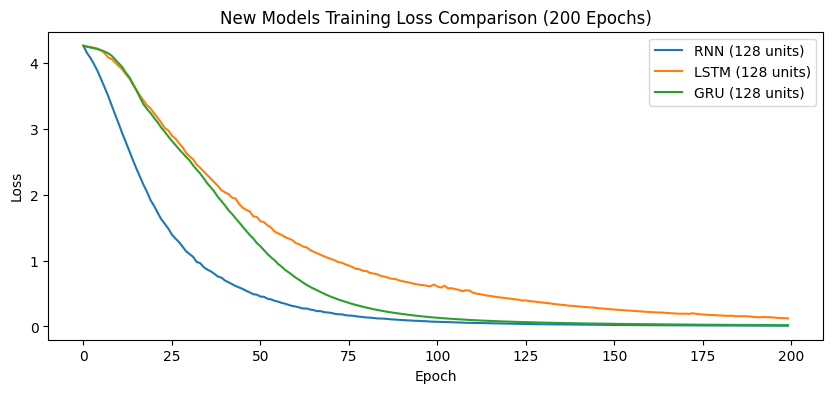

In [13]:
# 4. Compare Training Loss
plt.figure(figsize=(10,4))
plt.plot(new_rnn_history.history['loss'], label='RNN (128 units)')
plt.plot(new_lstm_history.history['loss'], label='LSTM (128 units)')
plt.plot(new_gru_history.history['loss'], label='GRU (128 units)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("New Models Training Loss Comparison (200 Epochs)")
plt.legend()
plt.show()


In [14]:
# 5. Text Generation Function for the new models
def generate_text_new(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = new_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=new_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in new_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Generate 10 words instead of 5
seed_phrase = "artificial intelligence"
print("RNN (10 words):", generate_text_new(new_rnn_model, seed_phrase, 10))
print("LSTM (10 words):", generate_text_new(new_lstm_model, seed_phrase, 10))
print("GRU (10 words):", generate_text_new(new_gru_model, seed_phrase, 10))


RNN (10 words): artificial intelligence is rapidly changing the way we interact with technology parameters
LSTM (10 words): artificial intelligence is rapidly changing the way we interact with technology technology
GRU (10 words): artificial intelligence is rapidly changing the way we interact with technology technology


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**